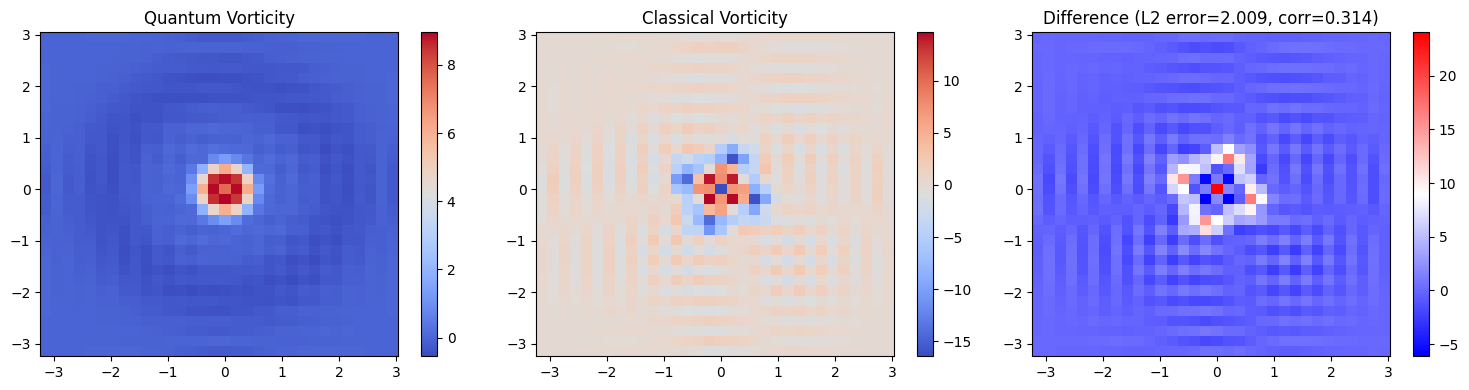

In [3]:
import numpy as np
from numpy import pi, exp, sqrt, real, imag
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Quantum output (reproducing your wave function setup)
N = 2**5
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
sigma = 3
f = np.exp(-(R/sigma)**4)
u = 2*(X + 1j*Y)*f / (1 + R**2)
v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
psi1_0 = u / np.sqrt(np.abs(u)**2 + np.abs(v)**4)
psi2_0 = v**2 / np.sqrt(np.abs(u)**2 + np.abs(v)**4)

# Compute ux, uy, vor from quantum wavefunction
def compute_fluid_quantities(psi1, psi2):
    kx = np.fft.fftfreq(N)*N
    ky = np.fft.fftfreq(N)*N
    KX, KY = np.meshgrid(kx, ky)
    psi1_spec = np.fft.fft2(psi1)
    dpsi1_x = np.fft.ifft2(1j*KX*psi1_spec)
    dpsi1_y = np.fft.ifft2(1j*KY*psi1_spec)
    psi2_spec = np.fft.fft2(psi2)
    dpsi2_x = np.fft.ifft2(1j*KX*psi2_spec)
    dpsi2_y = np.fft.ifft2(1j*KY*psi2_spec)
    rho = np.abs(psi1)**2 + np.abs(psi2)**2
    ux = real(real(psi1)*imag(dpsi1_x) - imag(psi1)*real(dpsi1_x) + real(psi2)*imag(dpsi2_x) - imag(psi2)*real(dpsi2_x)) / rho
    uy = real(real(psi1)*imag(dpsi1_y) - imag(psi1)*real(dpsi1_y) + real(psi2)*imag(dpsi2_y) - imag(psi2)*real(dpsi2_y)) / rho
    vor = real(np.fft.ifft2(1j*KX*np.fft.fft2(uy) - 1j*KY*np.fft.fft2(ux)))
    return ux, uy, vor

ux_q, uy_q, vor_q = compute_fluid_quantities(psi1_0, psi2_0)

# Classical FDM simulation
def ddx(f, dx): return (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2 * dx)
def ddy(f, dy): return (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2 * dy)
def laplacian(f, dx): return (np.roll(f, -1, axis=1) + np.roll(f, 1, axis=1) + np.roll(f, -1, axis=0) + np.roll(f, 1, axis=0) - 4 * f) / dx**2

def project(u, v, dx, dy):
    div = ddx(u, dx) + ddy(v, dy)
    p = np.zeros_like(u)
    for _ in range(100):
        p = 0.25 * (np.roll(p, 1, axis=0) + np.roll(p, -1, axis=0) + np.roll(p, 1, axis=1) + np.roll(p, -1, axis=1) - dx**2 * div)
    u -= ddx(p, dx)
    v -= ddy(p, dy)
    return u, v

def solve_classical_ns_fdm(ux0, uy0, dt=1.0, nu=0.05):
    dx = dy = 2 * pi / ux0.shape[0]
    u = ux0.copy()
    v = uy0.copy()
    u_new = u + dt * (-u * ddx(u, dx) - v * ddy(u, dy) + nu * laplacian(u, dx))
    v_new = v + dt * (-u * ddx(v, dx) - v * ddy(v, dy) + nu * laplacian(v, dx))
    u_proj, v_proj = project(u_new, v_new, dx, dy)
    vorticity = ddy(u_proj, dy) - ddx(v_proj, dx)
    return u_proj, v_proj, vorticity

ux_c, uy_c, vor_c = solve_classical_ns_fdm(ux_q, uy_q, dt=3.0, nu=0.05)

# Compute L2 error and correlation
l2_error = np.linalg.norm(vor_q - vor_c) / np.linalg.norm(vor_q)
corr, _ = pearsonr(vor_q.flatten(), vor_c.flatten())

# Plot comparison
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
pcm0 = axs[0].pcolormesh(X, Y, vor_q, cmap='coolwarm', shading='auto')
axs[0].set_title('Quantum Vorticity')
fig.colorbar(pcm0, ax=axs[0])

pcm1 = axs[1].pcolormesh(X, Y, vor_c, cmap='coolwarm', shading='auto')
axs[1].set_title('Classical Vorticity')
fig.colorbar(pcm1, ax=axs[1])

pcm2 = axs[2].pcolormesh(X, Y, vor_q - vor_c, cmap='bwr', shading='auto')
axs[2].set_title(f'Difference (L2 error={l2_error:.3f}, corr={corr:.3f})')
fig.colorbar(pcm2, ax=axs[2])

plt.tight_layout()
plt.show()
